# 06 — Statistical Tests: Woody Cover Fire Trajectories

Non-parametric group comparisons for **Landcover classes** and **Ecoregions**.

**Tests:**
- **A** Kruskal-Wallis + Dunn post-hoc: LC classes (Europe-wide)
- **B** Kruskal-Wallis: LC classes within each ecoregion
- **C** Kruskal-Wallis + Dunn post-hoc: Ecoregion comparison
- **D** Spearman correlation: Pre-fire woody cover vs. 5-year recovery

**Metrics per pixel** (single-fire pixels only):
`pre_fire_mean` · `pre_fire_trend` · `fire_loss` · `fire_loss_pct` · `recovery_5yr_pct`

**Output:** `09_Results/Statistics/{plots,csv}`

In [2]:
# ============================================================
# CELL 1 — CONFIGURATION & IMPORTS
# ============================================================

import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
from tqdm import tqdm
import os

# === Work directory ===
_workDir_remote = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis"
_workDir_local  = r"D:\Seafile\Meine Bibliothek\uni\master\thesis"
workDir = _workDir_local
print(f"workDir: {workDir}")

# === Temporal configuration ===
years_woody    = list(range(1985, 2025))   # 40 bands (1985–2024)
years_burned   = list(range(2001, 2026))   # 25 years (2001–2025)
MBA_START_YEAR = 2000
band_structure = [
    "burned", "count", "doy_1", "doy_2", "doy_3", "doy_4",
    "doy_min", "doy_max", "doy_span", "month_first", "month_last", "season_length"
]
modis_years = list(range(2001, 2025))      # 24 bands (2001–2024)

# === File paths ===
woody_path  = os.path.join(workDir, r"_Runs\02_Woody_Cover\woody_cover_500m_3035.tif")
burned_path = os.path.join(workDir, r"_Runs\01_Fire_Metrics\MBA_500m_3035_DOY_season\MBA_burned_metrics_yearly_season_500m_mosaic.tif")
ecoregion_raster_path = os.path.join(workDir, r"_Runs\03_Ecoregions_EEA\ecoregions_500m_3035_MBA.tif")
ecoregion_attr_path   = os.path.join(workDir, r"_Runs\03_Ecoregions_EEA\ecoregions_attributes_with_colors.csv")
modis_path = os.path.join(workDir, r"_Runs\04_Landcover\MODIS_GEE_tiles\MODIS_IGBP_2001_2024_500m_wildE.tif")

# === Exclusions ===
ECO_EXCLUDE = {'OUT'}
SKIP_MAJOR_IDS = {0, 7, 9, 10}   # NoData, Urban, Water, Other

# === Statistical test configuration ===
METRICS_TO_TEST = ['pre_fire_mean', 'pre_fire_trend', 'fire_loss',
                   'fire_loss_pct', 'recovery_5yr_pct']

METRIC_LABELS = {
    'pre_fire_mean':    'Pre-Fire Mean Woody Cover (%)',
    'pre_fire_trend':   'Pre-Fire Trend (%/yr)',
    'fire_loss':        'Fire Loss (% absolute)',
    'fire_loss_pct':    'Fire Loss (% relative)',
    'recovery_5yr_pct': '5-Year Recovery (% of Loss)',
}

MAX_SAMPLES = 50000

# === Color definitions ===
LC_COLORS = {
    'Forests':       '#228B22',
    'Shrublands':    '#8B4513',
    'Open Woodland': '#DAA520',
    'Grasslands':    '#90EE90',
    'Wetlands':      '#4682B4',
    'Croplands':     '#FFD700',
}

MAJOR_LC_NAMES = ['', 'Forests', 'Shrublands', 'Open Woodland', 'Grasslands',
                  'Wetlands', 'Croplands', 'Urban', 'Barren/Ice', 'Water', 'Other']

# === Output directories ===
results_base   = os.path.join(workDir, "_Runs", "09_Results")
stats_plots_dir = os.path.join(results_base, "Statistics", "plots")
stats_csv_dir   = os.path.join(results_base, "Statistics", "csv")
for d in [stats_plots_dir, stats_csv_dir]:
    os.makedirs(d, exist_ok=True)

print("=" * 70)
print("STATISTICAL TESTS — WOODY COVER FIRE TRAJECTORIES")
print("=" * 70)
print(f"  Metrics:    {len(METRICS_TO_TEST)} ({', '.join(METRICS_TO_TEST)})")
print(f"  Max samples: {MAX_SAMPLES:,} per group")
print(f"  Output:     {stats_plots_dir}")
print(f"              {stats_csv_dir}")

workDir: D:\Seafile\Meine Bibliothek\uni\master\thesis
STATISTICAL TESTS — WOODY COVER FIRE TRAJECTORIES
  Metrics:    5 (pre_fire_mean, pre_fire_trend, fire_loss, fire_loss_pct, recovery_5yr_pct)
  Max samples: 50,000 per group
  Output:     D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Statistics\plots
              D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Statistics\csv


In [3]:
# ============================================================
# CELL 2 — LOAD DATA  (Steps 0 + 1 from 05_analysis_eco_lc)
# ============================================================

print("0. LADE DATEN")
print("-" * 70)

# --- Grid properties from woody raster ---
with rasterio.open(woody_path) as src:
    nodata    = src.nodata
    height    = src.height
    width     = src.width

# --- Woody Cover (40 bands, 1985–2024) ---
print("Lade Woody Cover (1985-2024)...")
with rasterio.open(woody_path) as src:
    woody = src.read()   # (40, H, W)
print(f"  ✓ Woody Cover: {woody.shape}")

# --- Burned Area (25 years, 2001–2025) ---
print(f"Lade Burned Area ({years_burned[0]}-{years_burned[-1]})...")
with rasterio.open(burned_path) as src:
    burned_band_indices = [
        1 + (year - MBA_START_YEAR) * len(band_structure)
        for year in years_burned
    ]
    burned = src.read(burned_band_indices)   # (25, H, W)
print(f"  ✓ Burned Area: {burned.shape}")

# --- MODIS IGBP (24 bands, 2001–2024) ---
print("Lade MODIS IGBP (2001-2024)...")
with rasterio.open(modis_path) as src:
    modis_igbp = src.read()   # (24, H, W)
print(f"  ✓ MODIS IGBP: {modis_igbp.shape}")

# --- Ecoregion raster & attributes ---
print("Lade Ecoregion-Raster...")
with rasterio.open(ecoregion_raster_path) as src:
    eco_raster = src.read(1)

ecoregion_df = pd.read_csv(ecoregion_attr_path)
eco_mapping = {}
for _, row in ecoregion_df.iterrows():
    eco_mapping[row['NUMERIC_ID']] = {
        'code':      row['code'],
        'name':      row['name'],
        'hex_color': row['hex_color']
    }

unique_eco_ids = np.array([
    eid for eid in np.unique(eco_raster[eco_raster > 0]).astype(int)
    if eco_mapping[eid]['code'] not in ECO_EXCLUDE
])
print(f"  ✓ Ecoregions: {len(unique_eco_ids)} (excl. {ECO_EXCLUDE})")

# ============================================================
# 1. PRE-FIRE LANDCOVER PER PIXEL
# ============================================================
print("\n1. BESTIMME PRE-FIRE LANDCOVER")
print("-" * 70)

igbp_to_major_id = np.array([
    0, 1, 1, 1, 1, 1, 2, 2, 3, 3, 4, 5, 6, 7, 6, 8, 8, 9
], dtype=np.uint8)

# Fire counts & first fire index
fire_counts = np.sum(burned == 1, axis=0)
has_fire = fire_counts > 0
first_fire_idx = np.argmax(burned == 1, axis=0)

# Pre-fire landcover (vectorized)
fire_year_values = np.array(years_burned)[first_fire_idx]
target_years = fire_year_values - 1
modis_idx = np.clip(target_years - modis_years[0], 0, len(modis_years) - 1)

rows, cols = np.where(has_fire)
pre_fire_lc = np.zeros((height, width), dtype=np.uint8)
pre_fire_lc[rows, cols] = modis_igbp[modis_idx[rows, cols], rows, cols]

invalid = (pre_fire_lc < 1) | (pre_fire_lc > 17)
pre_fire_lc[invalid] = 0

pre_fire_lc_major_id = igbp_to_major_id[pre_fire_lc]
pre_fire_lc_major_id[pre_fire_lc_major_id == 8] = 0   # exclude Barren/Ice

# Determine which major classes are present
unique_major = np.unique(pre_fire_lc_major_id[pre_fire_lc_major_id > 0])
major_classes_present = sorted(int(m) for m in unique_major if m not in SKIP_MAJOR_IDS)

print(f"✓ Pre-Fire LC zugeordnet für {np.sum(pre_fire_lc > 0):,} Pixel")
print(f"  Major LC Klassen: {[MAJOR_LC_NAMES[m] for m in major_classes_present]}")
print(f"  Single-fire Pixel: {np.sum(fire_counts == 1):,}")
print(f"  Multi-fire Pixel:  {np.sum(fire_counts > 1):,}")

# Free MODIS array (no longer needed)
del modis_igbp
print(f"\n✓ Daten geladen — bereit für statistische Tests")

0. LADE DATEN
----------------------------------------------------------------------
Lade Woody Cover (1985-2024)...
  ✓ Woody Cover: (40, 9660, 10483)
Lade Burned Area (2001-2025)...
  ✓ Burned Area: (25, 9660, 10483)
Lade MODIS IGBP (2001-2024)...
  ✓ MODIS IGBP: (24, 9660, 10483)
Lade Ecoregion-Raster...
  ✓ Ecoregions: 11 (excl. {'OUT'})

1. BESTIMME PRE-FIRE LANDCOVER
----------------------------------------------------------------------
✓ Pre-Fire LC zugeordnet für 4,300,774 Pixel
  Major LC Klassen: ['Forests', 'Shrublands', 'Open Woodland', 'Grasslands', 'Wetlands', 'Croplands']
  Single-fire Pixel: 2,598,890
  Multi-fire Pixel:  1,701,884

✓ Daten geladen — bereit für statistische Tests


In [4]:
# ============================================================
# CELL 3 — HELPER FUNCTIONS
# ============================================================

def extract_pixel_metrics(woody, fire_counts, first_fire_idx, mask,
                          years_woody, years_burned, nodata,
                          max_samples=50000):
    """
    Extract per-pixel fire-response metrics for single-fire pixels within mask.
    Fully vectorized — no Python loops over pixels.

    Returns dict with numpy arrays per metric, or None if < 30 valid pixels.
    """
    single_fire_mask = (fire_counts == 1) & mask
    n_total = int(np.sum(single_fire_mask))
    if n_total < 30:
        return None

    ys, xs = np.where(single_fire_mask)

    # --- Subsample if too many pixels ---
    if n_total > max_samples:
        rng = np.random.RandomState(42)
        idx = rng.choice(n_total, max_samples, replace=False)
        ys, xs = ys[idx], xs[idx]
    n_sampled = len(ys)

    # --- Band offset: map fire index (in years_burned) to woody band ---
    # fire_band = first_fire_idx + offset  gives the woody band of the fire year
    offset = years_burned[0] - years_woody[0]   # 2001 - 1985 = 16
    fire_band = first_fire_idx[ys, xs].astype(np.int32) + offset   # shape (n,)

    n_woody_bands = len(years_woody)

    # --- 1) Pre-fire mean (mean of rel_years -5 to -1) ---
    pre_fire_vals = np.full((n_sampled, 5), np.nan)
    for k, rel in enumerate(range(-5, 0)):
        band_idx = fire_band + rel
        valid = (band_idx >= 0) & (band_idx < n_woody_bands)
        vals = np.where(valid, woody[np.clip(band_idx, 0, n_woody_bands - 1), ys, xs], np.nan)
        vals = np.where(valid & (vals != nodata), vals.astype(float), np.nan)
        pre_fire_vals[:, k] = vals

    pre_fire_mean = np.nanmean(pre_fire_vals, axis=1)

    # --- 2) Pre-fire trend (OLS slope over 5 pre-fire years) ---
    x_trend = np.arange(5, dtype=float)
    x_mean = x_trend.mean()
    x_var = np.sum((x_trend - x_mean) ** 2)
    y_centered = pre_fire_vals - np.nanmean(pre_fire_vals, axis=1, keepdims=True)
    # Vectorized slope: sum((x - x_mean) * y) / sum((x - x_mean)^2)
    x_centered = x_trend - x_mean
    # Handle NaN: use nansum but count valid
    numerator = np.nansum(pre_fire_vals * x_centered, axis=1) - \
                np.nansum(np.where(np.isnan(pre_fire_vals), 0, 1), axis=1) * 0  # placeholder
    # Cleaner approach: manual OLS with NaN handling
    pre_fire_trend = np.full(n_sampled, np.nan)
    n_valid_per_pixel = np.sum(~np.isnan(pre_fire_vals), axis=1)
    enough = n_valid_per_pixel >= 3
    if np.any(enough):
        idx_e = np.where(enough)[0]
        for i in idx_e:
            y_i = pre_fire_vals[i]
            valid_k = ~np.isnan(y_i)
            if np.sum(valid_k) >= 3:
                slope, _ = np.polyfit(x_trend[valid_k], y_i[valid_k], 1)
                pre_fire_trend[i] = slope

    # --- 3) Fire loss (absolute): woody[fire_band - 1] - woody[fire_band] ---
    band_pre  = fire_band - 1
    band_fire = fire_band
    valid_loss = (band_pre >= 0) & (band_fire < n_woody_bands)
    val_pre  = np.where(valid_loss,
                        woody[np.clip(band_pre, 0, n_woody_bands-1), ys, xs].astype(float),
                        np.nan)
    val_fire = np.where(valid_loss,
                        woody[np.clip(band_fire, 0, n_woody_bands-1), ys, xs].astype(float),
                        np.nan)
    val_pre  = np.where((val_pre != nodata) & valid_loss, val_pre, np.nan)
    val_fire = np.where((val_fire != nodata) & valid_loss, val_fire, np.nan)
    fire_loss = val_pre - val_fire

    # --- 4) Fire loss percent (relative to year before fire) ---
    fire_loss_pct = np.where(val_pre > 0, fire_loss / val_pre * 100, np.nan)

    # --- 5) 5-year recovery (% of loss recovered after 5 years) ---
    band_rec5 = fire_band + 5
    valid_rec = valid_loss & (band_rec5 < n_woody_bands)
    val_rec5 = np.where(valid_rec,
                        woody[np.clip(band_rec5, 0, n_woody_bands-1), ys, xs].astype(float),
                        np.nan)
    val_rec5 = np.where((val_rec5 != nodata) & valid_rec, val_rec5, np.nan)
    recovery_5yr_pct = np.where(
        (fire_loss > 0) & valid_rec,
        (val_rec5 - val_fire) / fire_loss * 100,
        np.nan
    )

    return {
        'pre_fire_mean':    pre_fire_mean,
        'pre_fire_trend':   pre_fire_trend,
        'fire_loss':        fire_loss,
        'fire_loss_pct':    fire_loss_pct,
        'recovery_5yr_pct': recovery_5yr_pct,
        'n_pixels_total':   n_total,
        'n_pixels_sampled': n_sampled,
    }


def kruskal_wallis_with_effect_size(groups, group_names, metric_name):
    """
    Kruskal-Wallis H-test with eta-squared effect size.
    Returns result dict or None if fewer than 2 valid groups.
    """
    clean = [(name, g[~np.isnan(g)]) for name, g in zip(group_names, groups)]
    clean = [(name, g) for name, g in clean if len(g) > 0]
    if len(clean) < 2:
        return None

    names  = [c[0] for c in clean]
    arrays = [c[1] for c in clean]

    H_stat, p_value = stats.kruskal(*arrays)

    n_total = sum(len(a) for a in arrays)
    k = len(arrays)
    eta_sq = max(0.0, (H_stat - k + 1) / (n_total - k))
    eta_sq = min(eta_sq, 1.0)

    if eta_sq < 0.01:
        effect = "negligible"
    elif eta_sq < 0.06:
        effect = "small"
    elif eta_sq < 0.14:
        effect = "medium"
    else:
        effect = "large"

    return {
        'metric':       metric_name,
        'H_stat':       H_stat,
        'p_value':      p_value,
        'eta_squared':  eta_sq,
        'effect_size':  effect,
        'k_groups':     k,
        'n_total':      n_total,
        'medians':      [float(np.median(a)) for a in arrays],
        'n_per_group':  [len(a) for a in arrays],
        'group_names':  names,
    }


print("✓ Helper-Funktionen geladen: extract_pixel_metrics(), kruskal_wallis_with_effect_size()")

✓ Helper-Funktionen geladen: extract_pixel_metrics(), kruskal_wallis_with_effect_size()


In [5]:
# ============================================================
# CELL 4 — RUN TESTS A–D
# ============================================================
import time
t0 = time.time()

# Helper: eco code → color / name
eco_color_map = {v['code']: v['hex_color'] for v in eco_mapping.values()}
eco_name_map  = {v['code']: v['name']      for v in eco_mapping.values()}

# =====================================================
# TEST A: Kruskal-Wallis — LC classes (Europe-wide)
# =====================================================
print("=" * 70)
print("TEST A: Kruskal-Wallis — Major Landcover Klassen (Europa-weit)")
print("=" * 70)

lc_pixel_metrics = {}

for major_id in tqdm(major_classes_present, desc="LC Pixel-Metriken"):
    lc_name = MAJOR_LC_NAMES[major_id]
    mask = (pre_fire_lc_major_id == major_id)
    metrics = extract_pixel_metrics(
        woody, fire_counts, first_fire_idx, mask,
        years_woody, years_burned, nodata,
        max_samples=MAX_SAMPLES
    )
    if metrics is not None:
        lc_pixel_metrics[lc_name] = metrics
        print(f"  ✓ {lc_name}: {metrics['n_pixels_total']:,} "
              f"(sampled: {metrics['n_pixels_sampled']:,})")

lc_names_ordered = sorted(lc_pixel_metrics.keys())

kw_results_lc = {}
for metric in METRICS_TO_TEST:
    groups = [lc_pixel_metrics[lc][metric] for lc in lc_names_ordered]
    result = kruskal_wallis_with_effect_size(groups, lc_names_ordered, metric)
    if result is not None:
        kw_results_lc[metric] = result
        sig = "***" if result['p_value'] < 0.001 else (
              "**"  if result['p_value'] < 0.01  else (
              "*"   if result['p_value'] < 0.05  else "n.s."))
        print(f"\n  {METRIC_LABELS[metric]}:")
        print(f"    H = {result['H_stat']:.1f}, p = {result['p_value']:.2e} {sig}")
        print(f"    η² = {result['eta_squared']:.4f} ({result['effect_size']})")

# =====================================================
# TEST B: Kruskal-Wallis — LC within each Ecoregion
# =====================================================
print("\n" + "=" * 70)
print("TEST B: Kruskal-Wallis — LC-Klassen innerhalb jeder Ecoregion")
print("=" * 70)

kw_results_lc_per_eco = {}

for eco_id in tqdm(unique_eco_ids, desc="Eco × LC Tests"):
    eco_code = eco_mapping[eco_id]['code']
    eco_mask = (eco_raster == eco_id)

    eco_lc_metrics = {}
    for major_id in major_classes_present:
        lc_name = MAJOR_LC_NAMES[major_id]
        mask = (pre_fire_lc_major_id == major_id) & eco_mask
        metrics = extract_pixel_metrics(
            woody, fire_counts, first_fire_idx, mask,
            years_woody, years_burned, nodata,
            max_samples=20000
        )
        if metrics is not None:
            eco_lc_metrics[lc_name] = metrics

    if len(eco_lc_metrics) < 2:
        continue

    kw_results_lc_per_eco[eco_code] = {}
    lc_names_eco = sorted(eco_lc_metrics.keys())

    for metric in METRICS_TO_TEST:
        groups = [eco_lc_metrics[lc][metric] for lc in lc_names_eco]
        result = kruskal_wallis_with_effect_size(groups, lc_names_eco, metric)
        if result is not None:
            kw_results_lc_per_eco[eco_code][metric] = result

print(f"  ✓ {len(kw_results_lc_per_eco)} Ecoregionen mit ≥2 LC-Klassen getestet")

# =====================================================
# TEST C: Kruskal-Wallis — Ecoregion comparison
# =====================================================
print("\n" + "=" * 70)
print("TEST C: Kruskal-Wallis — Ecoregion-Vergleich")
print("=" * 70)

eco_pixel_metrics = {}

for eco_id in tqdm(unique_eco_ids, desc="Eco Pixel-Metriken"):
    eco_code = eco_mapping[eco_id]['code']
    eco_mask = (eco_raster == eco_id)
    metrics = extract_pixel_metrics(
        woody, fire_counts, first_fire_idx, eco_mask,
        years_woody, years_burned, nodata,
        max_samples=MAX_SAMPLES
    )
    if metrics is not None:
        eco_pixel_metrics[eco_code] = metrics
        print(f"  ✓ {eco_code}: {metrics['n_pixels_total']:,} "
              f"(sampled: {metrics['n_pixels_sampled']:,})")

eco_names_ordered = sorted(eco_pixel_metrics.keys())

kw_results_eco = {}
for metric in METRICS_TO_TEST:
    groups = [eco_pixel_metrics[eco][metric] for eco in eco_names_ordered]
    result = kruskal_wallis_with_effect_size(groups, eco_names_ordered, metric)
    if result is not None:
        kw_results_eco[metric] = result
        sig = "***" if result['p_value'] < 0.001 else (
              "**"  if result['p_value'] < 0.01  else (
              "*"   if result['p_value'] < 0.05  else "n.s."))
        print(f"\n  {METRIC_LABELS[metric]}:")
        print(f"    H = {result['H_stat']:.1f}, p = {result['p_value']:.2e} {sig}")
        print(f"    η² = {result['eta_squared']:.4f} ({result['effect_size']})")

# =====================================================
# TEST D: Spearman — Pre-Fire WC vs 5-Year Recovery
# =====================================================
print("\n" + "=" * 70)
print("TEST D: Spearman-Korrelation — Pre-Fire WC vs 5-Year Recovery")
print("=" * 70)

spearman_results = {}

# D1: Per landcover class
print("\nPer Landcover:")
for lc_name in lc_names_ordered:
    m = lc_pixel_metrics[lc_name]
    x = m['pre_fire_mean']
    y = m['recovery_5yr_pct']
    valid = ~(np.isnan(x) | np.isnan(y))
    if np.sum(valid) > 30:
        rho, p = stats.spearmanr(x[valid], y[valid])
        spearman_results[f"LC_{lc_name}"] = {
            'group': lc_name, 'type': 'LC',
            'rho': rho, 'p_value': p, 'n': int(np.sum(valid))
        }
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        print(f"  {lc_name:20s}: ρ = {rho:+.3f}, p = {p:.2e} {sig}, n = {np.sum(valid):,}")

# D2: Per ecoregion
print("\nPer Ecoregion:")
for eco_code in eco_names_ordered:
    m = eco_pixel_metrics[eco_code]
    x = m['pre_fire_mean']
    y = m['recovery_5yr_pct']
    valid = ~(np.isnan(x) | np.isnan(y))
    if np.sum(valid) > 30:
        rho, p = stats.spearmanr(x[valid], y[valid])
        spearman_results[f"Eco_{eco_code}"] = {
            'group': eco_code, 'type': 'Ecoregion',
            'rho': rho, 'p_value': p, 'n': int(np.sum(valid))
        }
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        print(f"  {eco_code:20s}: ρ = {rho:+.3f}, p = {p:.2e} {sig}, n = {np.sum(valid):,}")

elapsed = time.time() - t0
print(f"\n✓ Alle Tests abgeschlossen ({elapsed:.1f}s)")
print(f"  Test A: {len(kw_results_lc)} Metriken × {len(lc_names_ordered)} LC Klassen")
print(f"  Test B: {len(kw_results_lc_per_eco)} Ecoregionen")
print(f"  Test C: {len(kw_results_eco)} Metriken × {len(eco_names_ordered)} Ecoregionen")
print(f"  Test D: {len(spearman_results)} Spearman-Korrelationen")

TEST A: Kruskal-Wallis — Major Landcover Klassen (Europa-weit)


LC Pixel-Metriken:   0%|          | 0/6 [00:00<?, ?it/s]C:\Users\Ruben\AppData\Local\Temp\ipykernel_27188\1994738237.py:84: RuntimeWarning: invalid value encountered in divide
  fire_loss_pct = np.where(val_pre > 0, fire_loss / val_pre * 100, np.nan)
C:\Users\Ruben\AppData\Local\Temp\ipykernel_27188\1994738237.py:95: RuntimeWarning: divide by zero encountered in divide
  (val_rec5 - val_fire) / fire_loss * 100,
C:\Users\Ruben\AppData\Local\Temp\ipykernel_27188\1994738237.py:95: RuntimeWarning: invalid value encountered in divide
  (val_rec5 - val_fire) / fire_loss * 100,
LC Pixel-Metriken:  17%|█▋        | 1/6 [00:10<00:53, 10.67s/it]

  ✓ Forests: 157,654 (sampled: 50,000)


C:\Users\Ruben\AppData\Local\Temp\ipykernel_27188\1994738237.py:84: RuntimeWarning: divide by zero encountered in divide
  fire_loss_pct = np.where(val_pre > 0, fire_loss / val_pre * 100, np.nan)
LC Pixel-Metriken:  33%|███▎      | 2/6 [00:12<00:20,  5.24s/it]

  ✓ Shrublands: 12,943 (sampled: 12,943)


...

Eco Pixel-Metriken:  91%|█████████ | 10/11 [00:31<00:03,  3.20s/it]

  ✓ Outside: 165,297 (sampled: 50,000)


Eco Pixel-Metriken: 100%|██████████| 11/11 [00:31<00:00,  2.88s/it]

  ✓ Arctic: 915 (sampled: 915)

  Pre-Fire Mean Woody Cover (%):
    H = 130708.2, p = 0.00e+00 ***
    η² = 0.3039 (large)

  Pre-Fire Trend (%/yr):
    H = 5127.0, p = 0.00e+00 ***
    η² = 0.0119 (small)

  Fire Loss (% absolute):
    H = 14170.5, p = 0.00e+00 ***
    η² = 0.0340 (small)



  Fire Loss (% relative):
    H = 13003.3, p = 0.00e+00 ***
    η² = 0.0335 (small)

  5-Year Recovery (% of Loss):
    H = 2641.2, p = 0.00e+00 ***
    η² = 0.0225 (small)

TEST D: Spearman-Korrelation — Pre-Fire WC vs 5-Year Recovery

Per Landcover:
  Croplands           : ρ = -0.121, p = 2.00e-44 ***, n = 13,297
  Forests             : ρ = -0.145, p = 3.57e-97 ***, n = 20,560
  Grasslands          : ρ = -0.058, p = 3.86e-12 ***, n = 14,320
  Open Woodland       : ρ = -0.104, p = 2.56e-41 ***, n = 16,674
  Shrublands          : ρ = -0.280, p = 1.14e-39 ***, n = 2,123
  Wetlands            : ρ = -0.010, p = 6.22e-01 n.s., n = 2,344

Per Ecoregion:
  Alpine              : ρ = -0.027, p = 1.84e-03 **, n = 13,618
  Anatolian           : ρ = -0.043, p = 5.83e-04 ***, n = 6,386
  Arctic              : ρ = -0.478, p = 1.62e-20 ***, n = 335
  Atlantic            : ρ = -0.020, p = 5.29e-02 n.s., n = 9,754
  BlackSea            : ρ = +0.011, p = 6.34e-01 n.s., n = 1,861
  Boreal              

In [6]:
# ============================================================
# CELL 5 — DUNN POST-HOC TESTS (FDR-BH correction)
# ============================================================

print("=" * 70)
print("DUNN POST-HOC TESTS (Benjamini-Hochberg FDR)")
print("=" * 70)

# =====================================================
# Dunn for TEST A (LC Europe-wide)
# =====================================================
print("\nTest A — Landcover pairwise:")
dunn_results_lc = {}

for metric in METRICS_TO_TEST:
    if metric not in kw_results_lc:
        continue
    # Build long-form DataFrame for scikit_posthocs
    all_values = []
    all_labels = []
    for lc in lc_names_ordered:
        vals = lc_pixel_metrics[lc][metric]
        mask_valid = ~np.isnan(vals)
        all_values.extend(vals[mask_valid].tolist())
        all_labels.extend([lc] * int(np.sum(mask_valid)))

    df_dunn = pd.DataFrame({'value': all_values, 'group': all_labels})
    p_matrix = sp.posthoc_dunn(df_dunn, val_col='value', group_col='group',
                                p_adjust='fdr_bh')
    dunn_results_lc[metric] = p_matrix

    # Count significant pairs
    n_sig = int(np.sum(p_matrix.values[np.triu_indices_from(p_matrix, k=1)] < 0.05))
    n_pairs = len(p_matrix) * (len(p_matrix) - 1) // 2
    print(f"  {metric}: {n_sig}/{n_pairs} Paare signifikant (p < 0.05)")

# =====================================================
# Dunn for TEST C (Ecoregion comparison)
# =====================================================
print("\nTest C — Ecoregion pairwise:")
dunn_results_eco = {}

for metric in METRICS_TO_TEST:
    if metric not in kw_results_eco:
        continue
    all_values = []
    all_labels = []
    for eco in eco_names_ordered:
        vals = eco_pixel_metrics[eco][metric]
        mask_valid = ~np.isnan(vals)
        all_values.extend(vals[mask_valid].tolist())
        all_labels.extend([eco] * int(np.sum(mask_valid)))

    df_dunn = pd.DataFrame({'value': all_values, 'group': all_labels})
    p_matrix = sp.posthoc_dunn(df_dunn, val_col='value', group_col='group',
                                p_adjust='fdr_bh')
    dunn_results_eco[metric] = p_matrix

    n_sig = int(np.sum(p_matrix.values[np.triu_indices_from(p_matrix, k=1)] < 0.05))
    n_pairs = len(p_matrix) * (len(p_matrix) - 1) // 2
    print(f"  {metric}: {n_sig}/{n_pairs} Paare signifikant (p < 0.05)")

print(f"\n✓ Dunn Post-hoc abgeschlossen: "
      f"{len(dunn_results_lc)} LC-Metriken, {len(dunn_results_eco)} Eco-Metriken")

DUNN POST-HOC TESTS (Benjamini-Hochberg FDR)

Test A — Landcover pairwise:
  pre_fire_mean: 15/15 Paare signifikant (p < 0.05)
  pre_fire_trend: 13/15 Paare signifikant (p < 0.05)
  fire_loss: 15/15 Paare signifikant (p < 0.05)
  fire_loss_pct: 15/15 Paare signifikant (p < 0.05)
  recovery_5yr_pct: 15/15 Paare signifikant (p < 0.05)

Test C — Ecoregion pairwise:
  pre_fire_mean: 53/55 Paare signifikant (p < 0.05)
  pre_fire_trend: 49/55 Paare signifikant (p < 0.05)
  fire_loss: 53/55 Paare signifikant (p < 0.05)
  fire_loss_pct: 53/55 Paare signifikant (p < 0.05)
  recovery_5yr_pct: 49/55 Paare signifikant (p < 0.05)

✓ Dunn Post-hoc abgeschlossen: 5 LC-Metriken, 5 Eco-Metriken


VISUALISIERUNGEN

Plot S1: Boxplots Landcover...
  ✓ boxplots_landcover.png


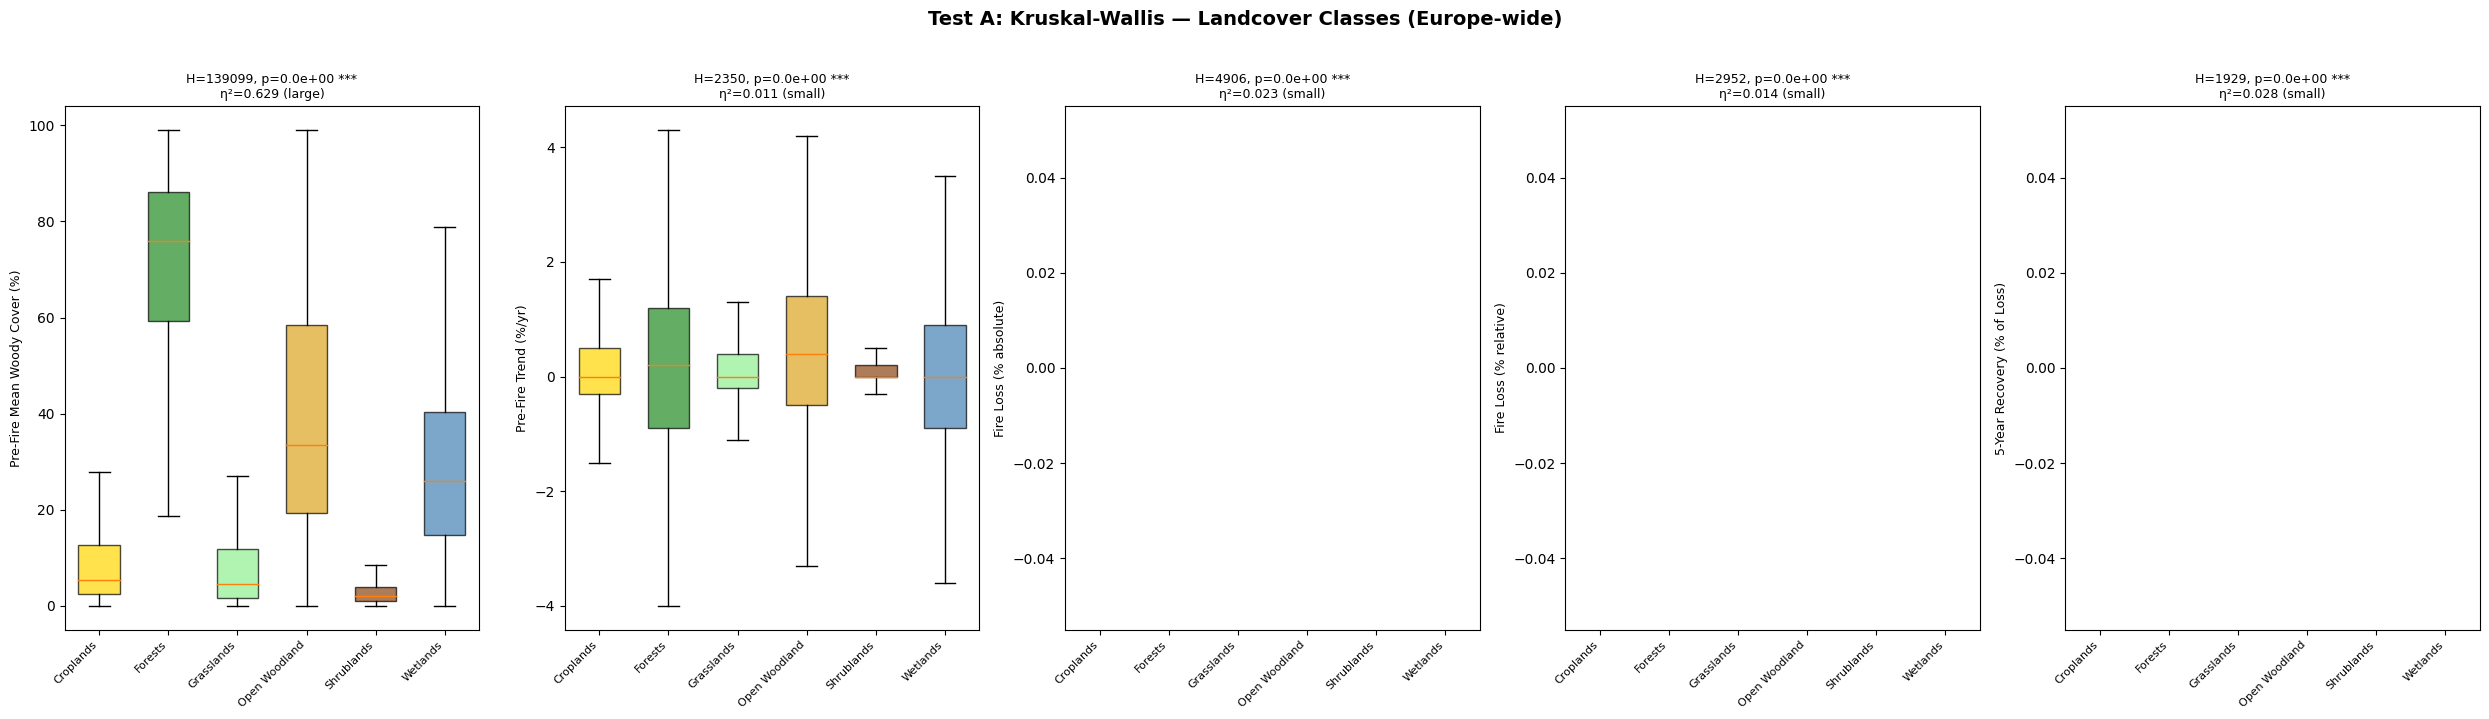


Plot S2: Boxplots Ecoregion...
  ✓ boxplots_ecoregion.png


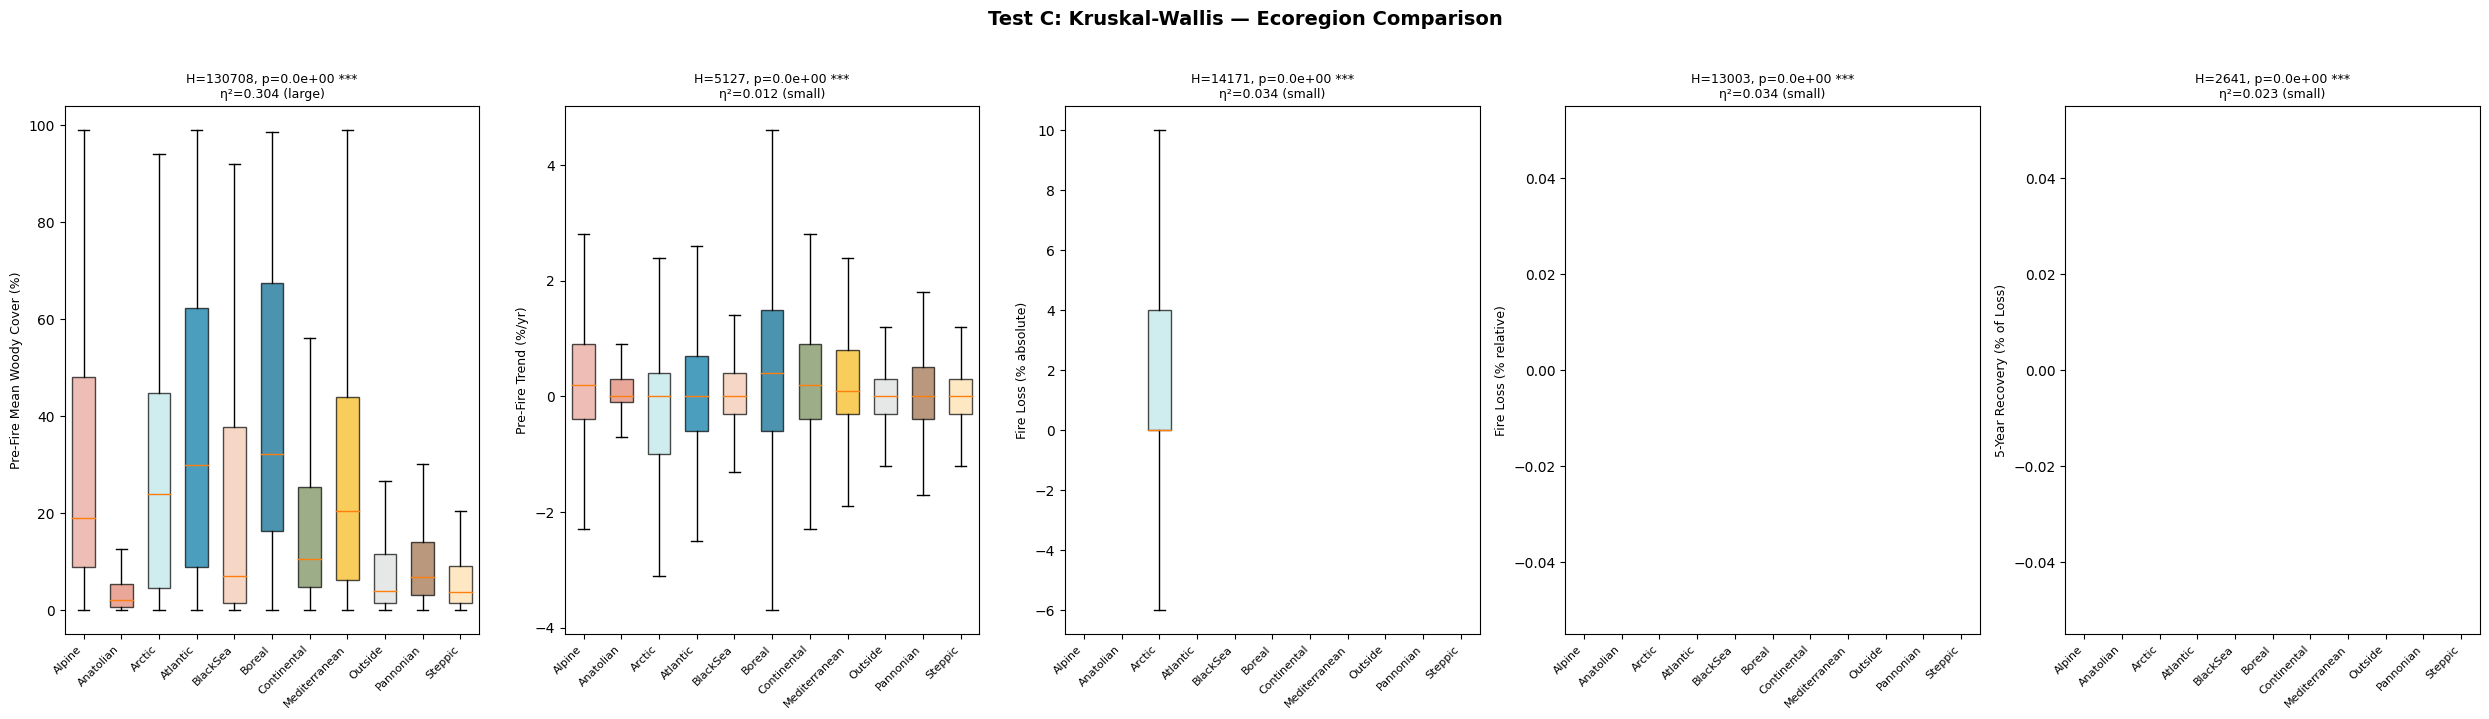


Plot S3: Dunn Heatmaps Landcover...


C:\Users\Ruben\AppData\Local\Temp\ipykernel_27188\876121450.py:97: RuntimeWarning: divide by zero encountered in log10
  log_p = np.clip(-np.log10(p_mat.values.astype(float)), 0, 50)


  ✓ dunn_heatmaps_landcover.png


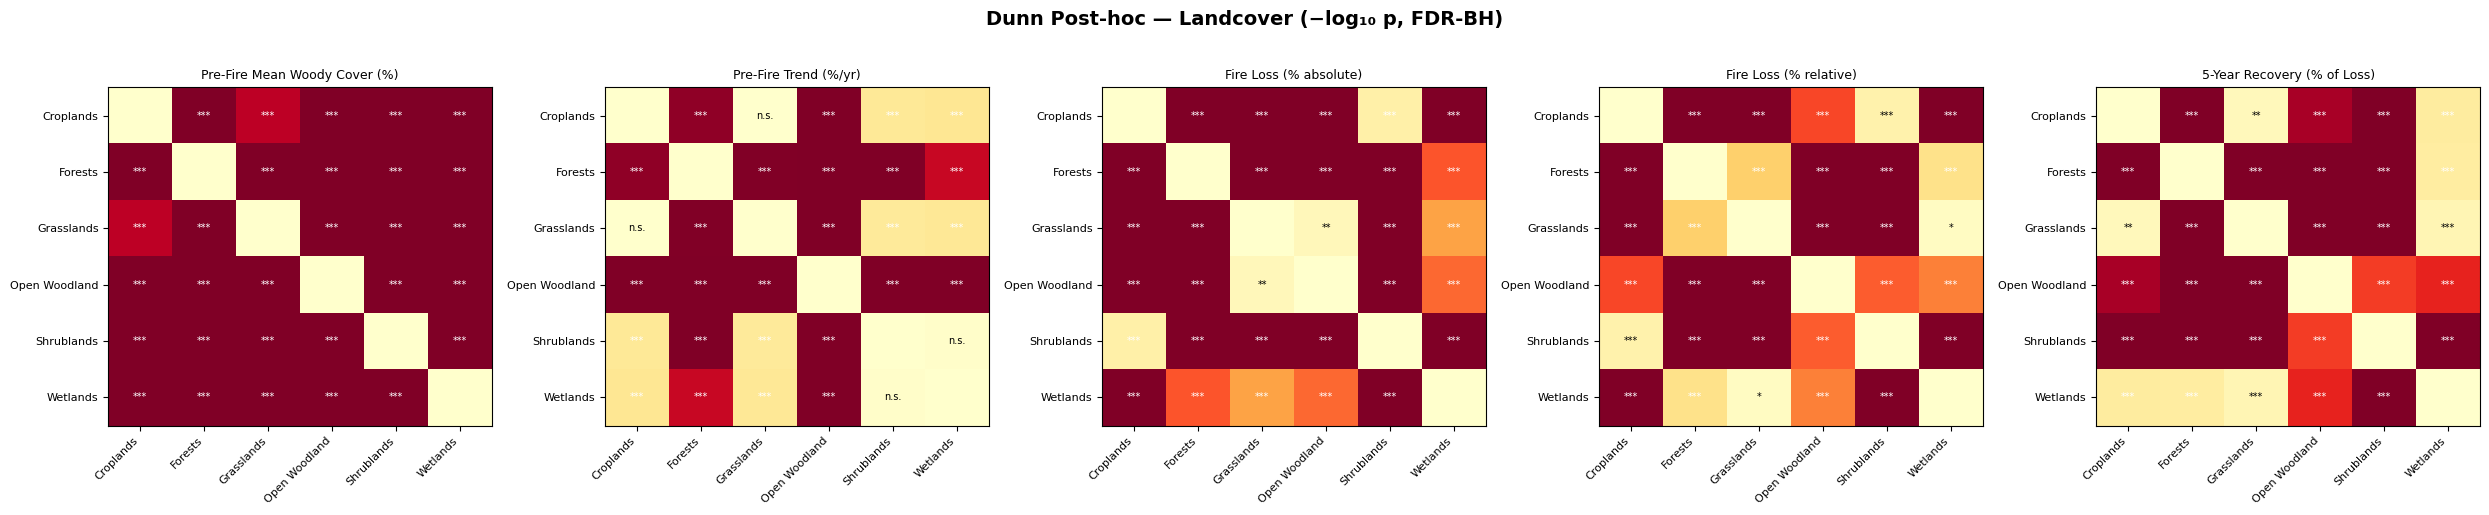


Plot S4: Dunn Heatmaps Ecoregion...


C:\Users\Ruben\AppData\Local\Temp\ipykernel_27188\876121450.py:141: RuntimeWarning: divide by zero encountered in log10
  log_p = np.clip(-np.log10(p_mat.values.astype(float)), 0, 50)


  ✓ dunn_heatmaps_ecoregion.png


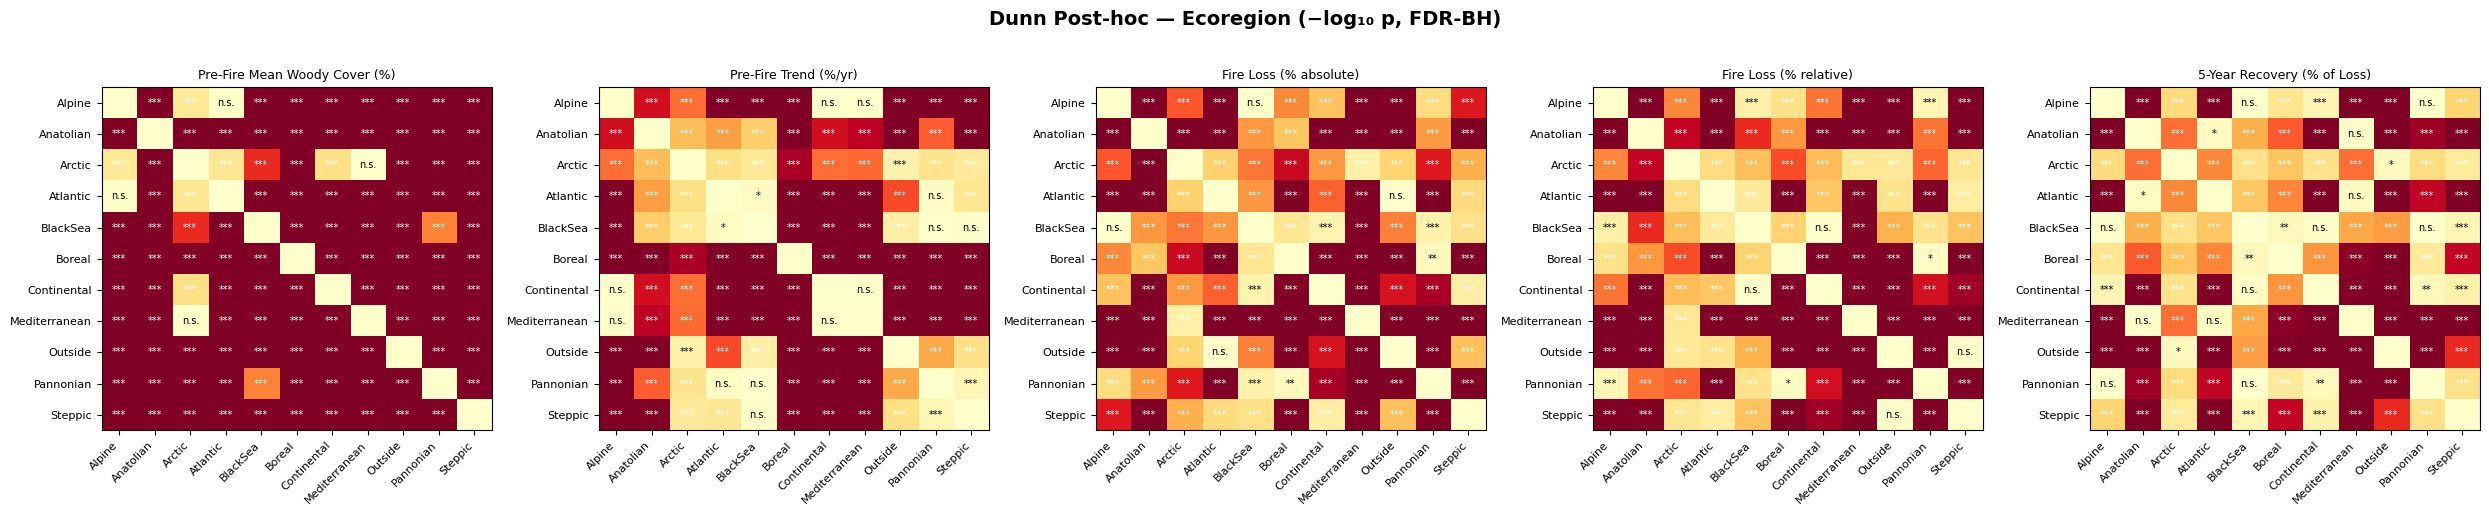


Plot S5: Effect Size Heatmap — LC per Ecoregion...
  ✓ effect_size_heatmap_lc_per_ecoregion.png


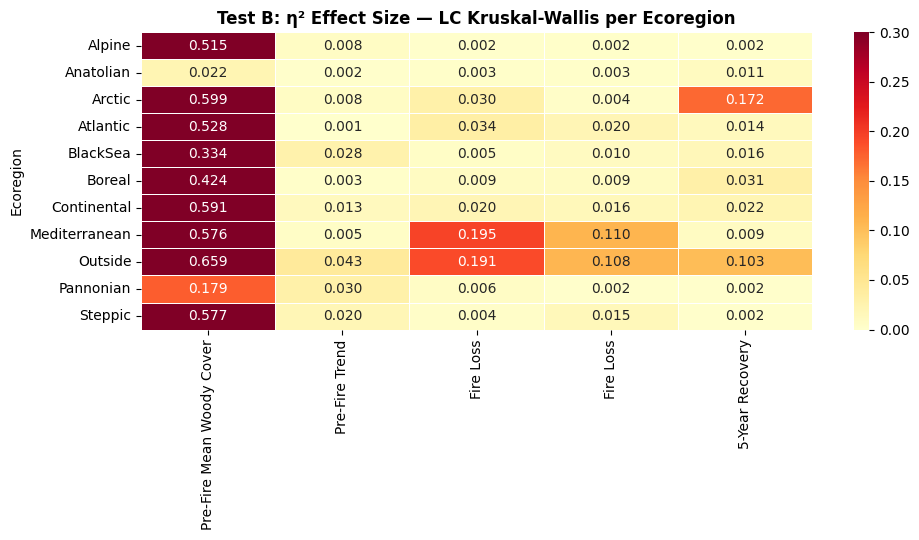


Plot S6: Spearman Scatter...
  ✓ spearman_scatter.png


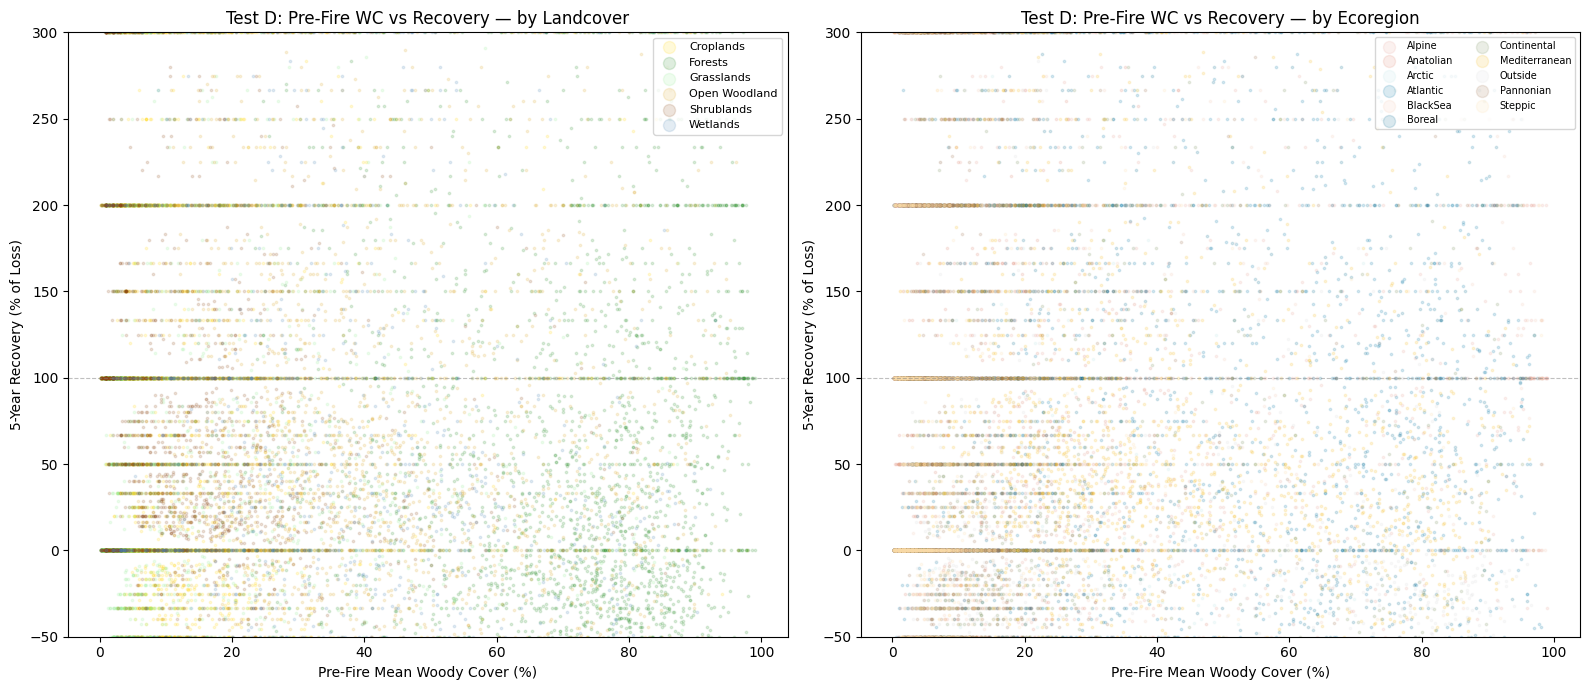


✓ Alle 6 Plots gespeichert in D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Statistics\plots


In [7]:
# ============================================================
# CELL 6 — VISUALIZATIONS
# ============================================================

print("=" * 70)
print("VISUALISIERUNGEN")
print("=" * 70)

# =====================================================
# S1: Boxplots — Landcover (Test A)
# =====================================================
print("\nPlot S1: Boxplots Landcover...")

fig, axes = plt.subplots(1, len(METRICS_TO_TEST), figsize=(5 * len(METRICS_TO_TEST), 7))
fig.suptitle('Test A: Kruskal-Wallis — Landcover Classes (Europe-wide)',
             fontsize=14, fontweight='bold', y=1.02)

for idx, metric in enumerate(METRICS_TO_TEST):
    ax = axes[idx]
    data = [lc_pixel_metrics[lc][metric] for lc in lc_names_ordered]
    bp = ax.boxplot(data, labels=lc_names_ordered, patch_artist=True,
                    showfliers=False, widths=0.6)

    for patch, lc in zip(bp['boxes'], lc_names_ordered):
        patch.set_facecolor(LC_COLORS.get(lc, '#cccccc'))
        patch.set_alpha(0.7)

    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

    if metric in kw_results_lc:
        r = kw_results_lc[metric]
        sig = "***" if r['p_value'] < 0.001 else ("**" if r['p_value'] < 0.01 else
              ("*" if r['p_value'] < 0.05 else "n.s."))
        ax.set_title(f"H={r['H_stat']:.0f}, p={r['p_value']:.1e} {sig}\n"
                     f"η²={r['eta_squared']:.3f} ({r['effect_size']})", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(stats_plots_dir, "boxplots_landcover.png"),
            dpi=300, bbox_inches='tight')
print("  ✓ boxplots_landcover.png")
plt.show()

# =====================================================
# S2: Boxplots — Ecoregion (Test C)
# =====================================================
print("\nPlot S2: Boxplots Ecoregion...")

fig, axes = plt.subplots(1, len(METRICS_TO_TEST), figsize=(5 * len(METRICS_TO_TEST), 7))
fig.suptitle('Test C: Kruskal-Wallis — Ecoregion Comparison',
             fontsize=14, fontweight='bold', y=1.02)

for idx, metric in enumerate(METRICS_TO_TEST):
    ax = axes[idx]
    data = [eco_pixel_metrics[eco][metric] for eco in eco_names_ordered]
    bp = ax.boxplot(data, labels=eco_names_ordered, patch_artist=True,
                    showfliers=False, widths=0.6)

    for patch, eco in zip(bp['boxes'], eco_names_ordered):
        patch.set_facecolor(eco_color_map.get(eco, '#cccccc'))
        patch.set_alpha(0.7)

    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

    if metric in kw_results_eco:
        r = kw_results_eco[metric]
        sig = "***" if r['p_value'] < 0.001 else ("**" if r['p_value'] < 0.01 else
              ("*" if r['p_value'] < 0.05 else "n.s."))
        ax.set_title(f"H={r['H_stat']:.0f}, p={r['p_value']:.1e} {sig}\n"
                     f"η²={r['eta_squared']:.3f} ({r['effect_size']})", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(stats_plots_dir, "boxplots_ecoregion.png"),
            dpi=300, bbox_inches='tight')
print("  ✓ boxplots_ecoregion.png")
plt.show()

# =====================================================
# S3: Dunn Heatmaps — Landcover (Test A)
# =====================================================
print("\nPlot S3: Dunn Heatmaps Landcover...")

fig, axes = plt.subplots(1, len(METRICS_TO_TEST),
                          figsize=(5 * len(METRICS_TO_TEST), 5))
fig.suptitle('Dunn Post-hoc — Landcover (−log₁₀ p, FDR-BH)',
             fontsize=14, fontweight='bold', y=1.02)

for idx, metric in enumerate(METRICS_TO_TEST):
    ax = axes[idx]
    if metric not in dunn_results_lc:
        ax.set_visible(False)
        continue
    p_mat = dunn_results_lc[metric]
    log_p = np.clip(-np.log10(p_mat.values.astype(float)), 0, 50)

    im = ax.imshow(log_p, cmap='YlOrRd', aspect='auto', vmin=0,
                   vmax=max(10, np.nanmax(log_p[np.isfinite(log_p)])))

    # Significance annotations
    for i in range(len(p_mat)):
        for j in range(len(p_mat)):
            if i == j:
                continue
            pv = p_mat.iloc[i, j]
            txt = '***' if pv < 0.001 else ('**' if pv < 0.01 else
                  ('*' if pv < 0.05 else 'n.s.'))
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if log_p[i, j] > 5 else 'black')

    ax.set_xticks(range(len(p_mat)))
    ax.set_yticks(range(len(p_mat)))
    ax.set_xticklabels(p_mat.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(p_mat.index, fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(stats_plots_dir, "dunn_heatmaps_landcover.png"),
            dpi=300, bbox_inches='tight')
print("  ✓ dunn_heatmaps_landcover.png")
plt.show()

# =====================================================
# S4: Dunn Heatmaps — Ecoregion (Test C)
# =====================================================
print("\nPlot S4: Dunn Heatmaps Ecoregion...")

fig, axes = plt.subplots(1, len(METRICS_TO_TEST),
                          figsize=(5 * len(METRICS_TO_TEST), 5))
fig.suptitle('Dunn Post-hoc — Ecoregion (−log₁₀ p, FDR-BH)',
             fontsize=14, fontweight='bold', y=1.02)

for idx, metric in enumerate(METRICS_TO_TEST):
    ax = axes[idx]
    if metric not in dunn_results_eco:
        ax.set_visible(False)
        continue
    p_mat = dunn_results_eco[metric]
    log_p = np.clip(-np.log10(p_mat.values.astype(float)), 0, 50)

    im = ax.imshow(log_p, cmap='YlOrRd', aspect='auto', vmin=0,
                   vmax=max(10, np.nanmax(log_p[np.isfinite(log_p)])))

    for i in range(len(p_mat)):
        for j in range(len(p_mat)):
            if i == j:
                continue
            pv = p_mat.iloc[i, j]
            txt = '***' if pv < 0.001 else ('**' if pv < 0.01 else
                  ('*' if pv < 0.05 else 'n.s.'))
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if log_p[i, j] > 5 else 'black')

    ax.set_xticks(range(len(p_mat)))
    ax.set_yticks(range(len(p_mat)))
    ax.set_xticklabels(p_mat.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(p_mat.index, fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(stats_plots_dir, "dunn_heatmaps_ecoregion.png"),
            dpi=300, bbox_inches='tight')
print("  ✓ dunn_heatmaps_ecoregion.png")
plt.show()

# =====================================================
# S5: Effect Size Heatmap — LC per Ecoregion (Test B)
# =====================================================
print("\nPlot S5: Effect Size Heatmap — LC per Ecoregion...")

eco_codes_b = sorted(kw_results_lc_per_eco.keys())
if len(eco_codes_b) > 0:
    eta_matrix = pd.DataFrame(index=eco_codes_b, columns=METRICS_TO_TEST, dtype=float)
    for eco_code in eco_codes_b:
        for metric in METRICS_TO_TEST:
            r = kw_results_lc_per_eco[eco_code].get(metric)
            eta_matrix.loc[eco_code, metric] = r['eta_squared'] if r else np.nan

    fig, ax = plt.subplots(figsize=(10, max(4, len(eco_codes_b) * 0.5)))
    sns.heatmap(eta_matrix.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=0.3, ax=ax, linewidths=0.5,
                xticklabels=[METRIC_LABELS[m].split('(')[0].strip() for m in METRICS_TO_TEST])
    ax.set_title('Test B: η² Effect Size — LC Kruskal-Wallis per Ecoregion',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Ecoregion')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.savefig(os.path.join(stats_plots_dir, "effect_size_heatmap_lc_per_ecoregion.png"),
                dpi=300, bbox_inches='tight')
    print("  ✓ effect_size_heatmap_lc_per_ecoregion.png")
    plt.show()
else:
    print("  ⚠️  Keine Test-B Ergebnisse vorhanden")

# =====================================================
# S6: Spearman Scatter — Pre-Fire WC vs Recovery (Test D)
# =====================================================
print("\nPlot S6: Spearman Scatter...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# S6a: colored by LC
ax = axes[0]
for lc_name in lc_names_ordered:
    m = lc_pixel_metrics[lc_name]
    x, y = m['pre_fire_mean'], m['recovery_5yr_pct']
    valid = ~(np.isnan(x) | np.isnan(y))
    # Subsample for plotting (max 5000 per class)
    n_plot = min(5000, int(np.sum(valid)))
    if n_plot < 10:
        continue
    rng = np.random.RandomState(42)
    plot_idx = rng.choice(np.sum(valid), n_plot, replace=False)
    ax.scatter(x[valid][plot_idx], y[valid][plot_idx],
               c=LC_COLORS.get(lc_name, '#999'), alpha=0.15, s=3,
               label=lc_name, rasterized=True)
ax.set_xlabel('Pre-Fire Mean Woody Cover (%)')
ax.set_ylabel('5-Year Recovery (% of Loss)')
ax.set_title('Test D: Pre-Fire WC vs Recovery — by Landcover')
ax.axhline(100, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=8, markerscale=5)
ax.set_ylim(-50, 300)

# S6b: colored by Ecoregion
ax = axes[1]
for eco_code in eco_names_ordered:
    m = eco_pixel_metrics[eco_code]
    x, y = m['pre_fire_mean'], m['recovery_5yr_pct']
    valid = ~(np.isnan(x) | np.isnan(y))
    n_plot = min(3000, int(np.sum(valid)))
    if n_plot < 10:
        continue
    rng = np.random.RandomState(42)
    plot_idx = rng.choice(np.sum(valid), n_plot, replace=False)
    ax.scatter(x[valid][plot_idx], y[valid][plot_idx],
               c=eco_color_map.get(eco_code, '#999'), alpha=0.15, s=3,
               label=eco_code, rasterized=True)
ax.set_xlabel('Pre-Fire Mean Woody Cover (%)')
ax.set_ylabel('5-Year Recovery (% of Loss)')
ax.set_title('Test D: Pre-Fire WC vs Recovery — by Ecoregion')
ax.axhline(100, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=7, markerscale=5, ncol=2)
ax.set_ylim(-50, 300)

plt.tight_layout()
plt.savefig(os.path.join(stats_plots_dir, "spearman_scatter.png"),
            dpi=300, bbox_inches='tight')
print("  ✓ spearman_scatter.png")
plt.show()

print(f"\n✓ Alle {6} Plots gespeichert in {stats_plots_dir}")

In [9]:
# ============================================================
# CELL 7 — CSV EXPORT
# ============================================================

print("=" * 70)
print("CSV EXPORT")
print("=" * 70)

# -------------------------------------------------------------
# 1) kruskal_wallis_landcover_europe.csv   (Test A)
# -------------------------------------------------------------
rows = []
for metric in METRICS_TO_TEST:
    if metric in kw_results_lc:
        r = kw_results_lc[metric]
        rows.append({'metric': metric, 'H_stat': r['H_stat'],
                     'p_value': r['p_value'], 'eta_squared': r['eta_squared'],
                     'effect_size': r['effect_size'],
                     'n_groups': r['k_groups'], 'n_total': r['n_total']})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "kruskal_wallis_landcover_europe.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

# -------------------------------------------------------------
# 2) kruskal_wallis_lc_per_ecoregion.csv   (Test B)
# -------------------------------------------------------------
rows = []
for eco_code, results in kw_results_lc_per_eco.items():
    for metric in METRICS_TO_TEST:
        r = results.get(metric)
        if r:
            rows.append({'ecoregion': eco_code, 'metric': metric,
                         'H_stat': r['H_stat'], 'p_value': r['p_value'],
                         'eta_squared': r['eta_squared'],
                         'effect_size': r['effect_size'],
                         'n_groups': r['k_groups'], 'n_total': r['n_total']})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "kruskal_wallis_lc_per_ecoregion.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

# -------------------------------------------------------------
# 3) kruskal_wallis_ecoregion.csv   (Test C)
# -------------------------------------------------------------
rows = []
for metric in METRICS_TO_TEST:
    if metric in kw_results_eco:
        r = kw_results_eco[metric]
        rows.append({'metric': metric, 'H_stat': r['H_stat'],
                     'p_value': r['p_value'], 'eta_squared': r['eta_squared'],
                     'effect_size': r['effect_size'],
                     'n_groups': r['k_groups'], 'n_total': r['n_total']})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "kruskal_wallis_ecoregion.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

# -------------------------------------------------------------
# 4) dunn_posthoc_lc_pairwise.csv   (Test A post-hoc)
# -------------------------------------------------------------
rows = []
for metric, p_mat in dunn_results_lc.items():
    for i in range(len(p_mat)):
        for j in range(i + 1, len(p_mat)):
            rows.append({'metric': metric,
                         'group_1': p_mat.index[i], 'group_2': p_mat.columns[j],
                         'p_value_adj': p_mat.iloc[i, j],
                         'significant_005': p_mat.iloc[i, j] < 0.05})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "dunn_posthoc_lc_pairwise.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

# -------------------------------------------------------------
# 5) dunn_posthoc_eco_pairwise.csv   (Test C post-hoc)
# -------------------------------------------------------------
rows = []
for metric, p_mat in dunn_results_eco.items():
    for i in range(len(p_mat)):
        for j in range(i + 1, len(p_mat)):
            rows.append({'metric': metric,
                         'group_1': p_mat.index[i], 'group_2': p_mat.columns[j],
                         'p_value_adj': p_mat.iloc[i, j],
                         'significant_005': p_mat.iloc[i, j] < 0.05})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "dunn_posthoc_eco_pairwise.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

# -------------------------------------------------------------
# 6) effect_sizes_overview.csv
# -------------------------------------------------------------
rows = []
for metric in METRICS_TO_TEST:
    # LC Europe (Test A)
    rA = kw_results_lc.get(metric)
    if rA:
        rows.append({'test': 'A_LC_Europe', 'grouping': 'Landcover',
                     'scope': 'Europe', 'metric': metric,
                     'H_stat': rA['H_stat'], 'p_value': rA['p_value'],
                     'eta_squared': rA['eta_squared'],
                     'effect_size': rA['effect_size']})
    # Eco (Test C)
    rC = kw_results_eco.get(metric)
    if rC:
        rows.append({'test': 'C_Ecoregion', 'grouping': 'Ecoregion',
                     'scope': 'Europe', 'metric': metric,
                     'H_stat': rC['H_stat'], 'p_value': rC['p_value'],
                     'eta_squared': rC['eta_squared'],
                     'effect_size': rC['effect_size']})
    # LC per Eco (Test B)
    for eco_code in sorted(kw_results_lc_per_eco.keys()):
        rB = kw_results_lc_per_eco[eco_code].get(metric)
        if rB:
            rows.append({'test': 'B_LC_per_Eco', 'grouping': 'Landcover',
                         'scope': eco_code, 'metric': metric,
                         'H_stat': rB['H_stat'], 'p_value': rB['p_value'],
                         'eta_squared': rB['eta_squared'],
                         'effect_size': rB['effect_size']})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "effect_sizes_overview.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

# -------------------------------------------------------------
# 7) spearman_correlations.csv   (Test D)
# -------------------------------------------------------------
rows = []
for key, vals in spearman_results.items():
    rows.append({'test': 'D_Spearman', 'grouping': vals['type'],
                 'group': vals['group'], 'rho': vals['rho'],
                 'p_value': vals['p_value'], 'n': vals['n']})
df = pd.DataFrame(rows)
fp = os.path.join(stats_csv_dir, "spearman_correlations.csv")
df.to_csv(fp, index=False)
print(f"✓ {os.path.basename(fp)}  ({len(df)} rows)")

print(f"\n✓ Alle CSV-Dateien gespeichert in {stats_csv_dir}")
print("=" * 70)
print("FERTIG — 06_statistical_tests.ipynb komplett abgeschlossen!")
print("=" * 70)

CSV EXPORT
✓ kruskal_wallis_landcover_europe.csv  (5 rows)
✓ kruskal_wallis_lc_per_ecoregion.csv  (55 rows)
✓ kruskal_wallis_ecoregion.csv  (5 rows)
✓ dunn_posthoc_lc_pairwise.csv  (75 rows)
✓ dunn_posthoc_eco_pairwise.csv  (275 rows)
✓ effect_sizes_overview.csv  (65 rows)
✓ spearman_correlations.csv  (17 rows)

✓ Alle CSV-Dateien gespeichert in D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Statistics\csv
FERTIG — 06_statistical_tests.ipynb komplett abgeschlossen!
